In [2]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Data paths
train_dir = r"C:\Users\tebje\Documents\HVLIT\GithubRepos\Image-Classification-Explainability-data\2\Fish_Dataset\Fish_Dataset\Fish_Dataset_clean"
img_size = (224, 224)
batch_size = 32

In [4]:
# Data generators
seed = 1337  # make split and ordering deterministic

train_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=seed
)

# Use a separate datagen for validation to be explicit and safe
val_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,   # don't shuffle for reproducible, aligned evaluation
    seed=seed
)

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.


In [5]:
print(val_generator.class_indices)

{'Black Sea Sprat': 0, 'Gilt-Head Bream': 1, 'Hourse Mackerel': 2, 'Red Mullet': 3, 'Red Sea Bream': 4, 'Sea Bass': 5, 'Shrimp': 6, 'Striped Red Mullet': 7, 'Trout': 8}


In [6]:
# Build model
base_model = MobileNetV3Large(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # or even 1e-5
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Train
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
 45/225 ━━━━━━━━━━━━━━━━━━━━ 2:44 911ms/step - accuracy: 0.1698 - loss: 2.1720

KeyboardInterrupt: 

In [ ]:
# Save model
from pathlib import Path

project_root = Path('/home/groggy/projects/Image-Classification-Explainability')
save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Basic_Laptoptest.keras'
model.save(save_path)
print('Model saved to disk.')

## light analysis

NameError: name 'history' is not defined

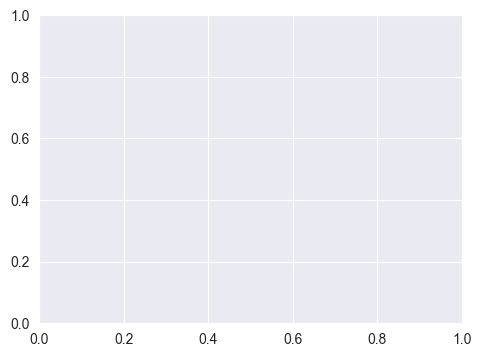

In [9]:
# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Image saved to: C:\Users\tebje\Documents\HVLIT\GithubRepos\Image-Classification-Explainability\ML\images\3x3-all-classes-overview.png


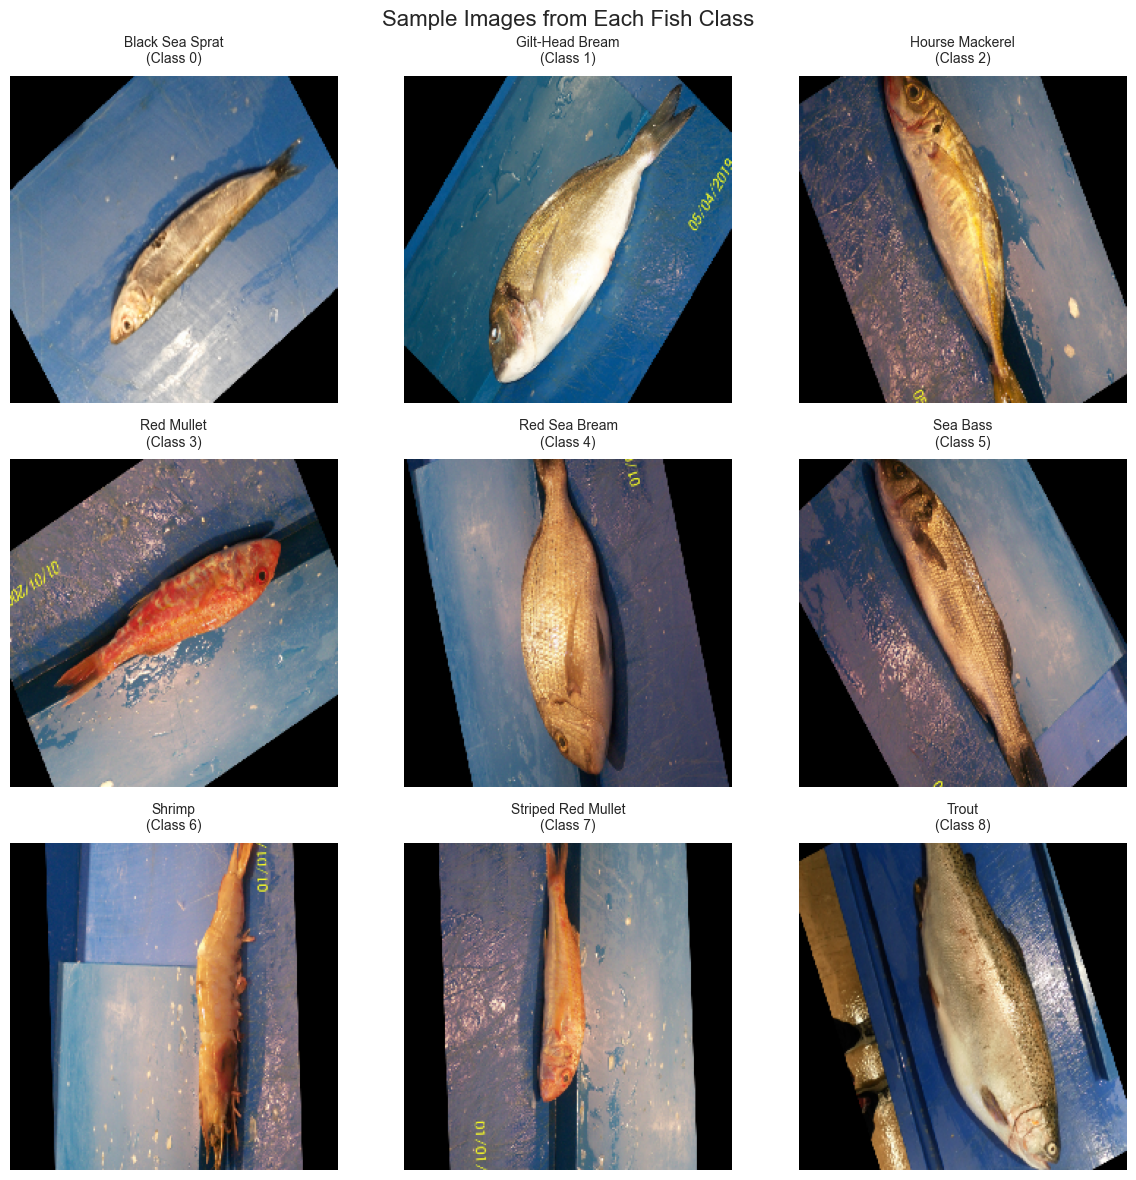

In [11]:
# Visualize sample images from each class in a 3x3 grid
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image
import numpy as np

# Get class names and their indices
class_indices = val_generator.class_indices
class_names = list(class_indices.keys())

# Create a 3x3 subplot
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Load and display one image from each class
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)

    # Get the first image file from this class directory
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if image_files:
        img_path = os.path.join(class_dir, image_files[0])

        # Load and display the image
        img = image.load_img(img_path, target_size=img_size)
        img_array = image.img_to_array(img) / 255.0  # Normalize for display

        axes[i].imshow(img_array)
        axes[i].set_title(f'{class_name}\n(Class {i})', fontsize=10, pad=10)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'No images\nfound for\n{class_name}',
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'{class_name}\n(Class {i})', fontsize=10, pad=10)
        axes[i].axis('off')

plt.suptitle('Sample Images from Each Fish Class', fontsize=16, y=0.98)
plt.tight_layout()

# Save the figure
save_path = r"C:\Users\tebje\Documents\HVLIT\GithubRepos\Image-Classification-Explainability\ML\images\3x3-all-classes-overview.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Image saved to: {save_path}")

plt.show()

## Validation diagnostics

In [48]:
# Inspect whether the model is predicting a single class on the validation set
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Build a non-shuffled validation iterator for aligned y_true/preds
val_eval = val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=seed
)

val_steps = int(np.ceil(val_eval.samples / val_eval.batch_size))

# Ground truth labels in the same order as yielded by val_eval
y_true = val_eval.classes

# Model predictions in the same order
preds = model.predict(val_eval, steps=val_steps, verbose=1)
y_pred = preds.argmax(axis=1)

print("Class indices (mapping):", val_eval.class_indices)

# Sanity checks
print("Validation samples:", val_eval.samples)
print("Validation class distribution (counts by class index):", np.bincount(y_true))
print("Predicted class distribution:", np.bincount(y_pred, minlength=preds.shape[1]))

# Manual accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Manual validation accuracy: {acc:.4f}")

# If the model predicts one class only, this will be a diagonal-less matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

# Optional detailed report (might be long)
print(classification_report(y_true, y_pred, zero_division=0))

Found 1800 images belonging to 9 classes.
57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 435ms/step
Class indices (mapping): {'Black Sea Sprat': 0, 'Gilt-Head Bream': 1, 'Hourse Mackerel': 2, 'Red Mullet': 3, 'Red Sea Bream': 4, 'Sea Bass': 5, 'Shrimp': 6, 'Striped Red Mullet': 7, 'Trout': 8}
Validation samples: 1800
Validation class distribution (counts by class index): [200 200 200 200 200 200 200 200 200]
Predicted class distribution: [   0    0    0    0    0 1800    0    0    0]
Manual validation accuracy: 0.1111
Confusion matrix:
 [[  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0 200   0   0   0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       200
           1